In [1]:
from qitf_model import *
import numpy as np
from entropy import *
from math import sqrt
import random as rand
from qiskit.quantum_info import Statevector, partial_trace
from tqdm import tqdm
trails=30
time_step=0.1
num_steps=60
final_time=6
sigma=0.001
N=10
d=2**N
exact_model = QITFModel(hx=0.809,J=1)
analog_model=[]
delta=[]
for i in range(trails):
    delta.append([(rand.normalvariate(0, sigma)) for _ in range(10)])
    analog_model.append(analog_QITF(exact_model, delta=delta[i], eta=0.001))

In [2]:
def eigenvector_corresponding_to_maximal_eigenvalue(matrix):
    eigenvalues, eigenvectors = eig(matrix)
    max_eigenvalue_index = np.argmax(np.abs(eigenvalues))
    return eigenvectors[:,max_eigenvalue_index]

disorder_term=time_step*sqrt(10)*0.001
imperfection_term=[]
imperfection_matrix=SparsePauliOp.from_sparse_list(exact_model.XX_tuples, num_qubits=N).to_matrix()
# initial_state = Statevector.from_label('0'*N).data
initial_state = eigenvector_corresponding_to_maximal_eigenvalue(imperfection_matrix)
entropy = []

state=initial_state
for i in tqdm(range(num_steps)):
    imp_temp=0
    for j in range(10):
        state=exact_model.get_evolution_segment(time_step/10)@state
        imp_temp+=time_step/10*0.001*np.linalg.norm(imperfection_matrix@state)
    imperfection_term.append(imp_temp)

100%|██████████| 60/60 [01:13<00:00,  1.22s/it]


In [3]:
empirical_error = np.zeros((num_steps,trails))
error_std = []
error_avg = []
for i in range(trails):
    state=initial_state
    for j in range(num_steps):
        exact_state = exact_model.one_step_evolve(state)
        analog_state = analog_model[i].one_step_evolve(state)
        empirical_error[j, i] = np.linalg.norm(exact_state - analog_state)
        state = exact_state
for i in range(num_steps):
    error_std.append(np.std(empirical_error[i, :]))
    error_avg.append(np.mean(empirical_error[i, :]))

In [4]:
disorder_avg = []
disorder_std = []
empirical_disorder = np.zeros((num_steps, trails))

for i in tqdm(range(trails)):
    state=initial_state
    disorder_matrix=analog_QITF(exact_model, delta=delta[i], eta=0).perm
    for j in range(num_steps):
        dis_temp=0
        for k in range(10):
            state=exact_model.get_evolution_segment(time_step/10)@state
            dis_temp+=time_step/10*np.linalg.norm(disorder_matrix@state)
        empirical_disorder[j, i] = dis_temp
for i in range(num_steps):
    disorder_std.append(np.std(empirical_disorder[i, :]))
    disorder_avg.append(np.mean(empirical_disorder[i, :]))

100%|██████████| 30/30 [30:36<00:00, 61.22s/it]


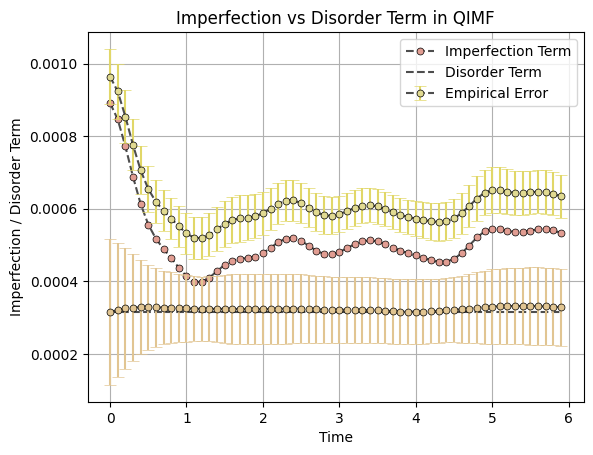

In [5]:
import matplotlib.pyplot as plt
time=np.linspace(0,final_time,num_steps+1)

plt.plot(time[:-1], imperfection_term,color='0.3', marker='o', markersize=5, mfc='#E19D92', mec='k', linestyle='dashed', markeredgewidth=0.5,label='Imperfection Term')
plt.plot(time[:-1], [disorder_term]*num_steps,color='0.3', marker='', markersize=5, mfc="#E1C592", mec='k', linestyle='dashed', markeredgewidth=0.5,label='Disorder Term')
plt.errorbar(time[:-1], error_avg, yerr=error_std, color='0.3', marker='o', markersize=5, ecolor="#e1d768", mfc="#E1DA92", mec='k', linestyle='dashed', markeredgewidth=0.5,label='Empirical Average Error',capsize=4)
plt.errorbar(time[:-1], disorder_avg, yerr=disorder_std, color='0.3', marker='o', markersize=5, ecolor="#e1c592", mfc="#e1c592", mec='k', linestyle='dashed', markeredgewidth=0.5,label='Empirical Disorder Term',capsize=4)
plt.xlabel('Time')
plt.ylabel('Imperfection / Disorder Term') 
plt.legend(['Imperfection Term','Disorder Term', 'Empirical Error'])
plt.title('Imperfection vs Disorder Term in QIMF')
plt.grid()